In [74]:
import numpy as np
from pathlib  import Path
import imageio.v3 as iio
import matplotlib.pyplot as plt
from model_ranking.utils import (
    load_h5,
)
from pytorch3dunet.augment.transforms import Normalize

In [79]:
from numpy.typing import NDArray
from typing import Any
from skimage import exposure

def enhance_image(im: NDArray[Any], do_norm:bool=True)->NDArray[Any]:
    # apply CLAHE to improve the image quality
    if do_norm:
        im -= im.min(axis=(0, 1), keepdims=True)
        im /= (im.max(axis=(0, 1), keepdims=True) + 1e-6)
    im = exposure.equalize_adapthist(im) #pyright: ignore
    im *= 255 #pyright: ignore
    return im #pyright: ignore

# Hoechst Data

In [6]:
Hst_gt_path = Path("/g/kreshuk/talks/data/Hoechst/test_nuclei/annotations")
Hst_raw_path = Path("/g/kreshuk/talks/data/Hoechst/test_nuclei/images/png")

### 1196_model3 Predictions

In [10]:
m1196_to_Hst_pred_path = Path("/g/kreshuk/talks/consistency_results/patch_segmentation/nuclei/S_BIAD1196_to_Hoechst_gap/consistency/P_1/1196_model3/norm_50_980/none/predictions")
m1196_to_Hst_p_pred_path = Path("/g/kreshuk/talks/consistency_results/patch_segmentation/nuclei/S_BIAD1196_to_Hoechst_gap/consistency/P_1/1196_model3/norm_50_980/gauss_a025-03/predictions")

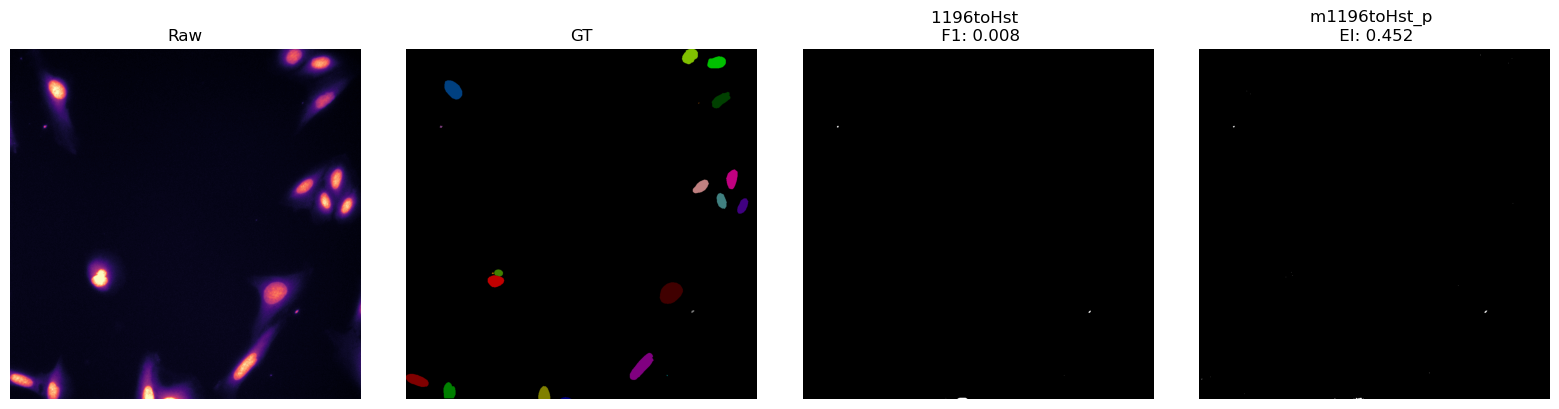

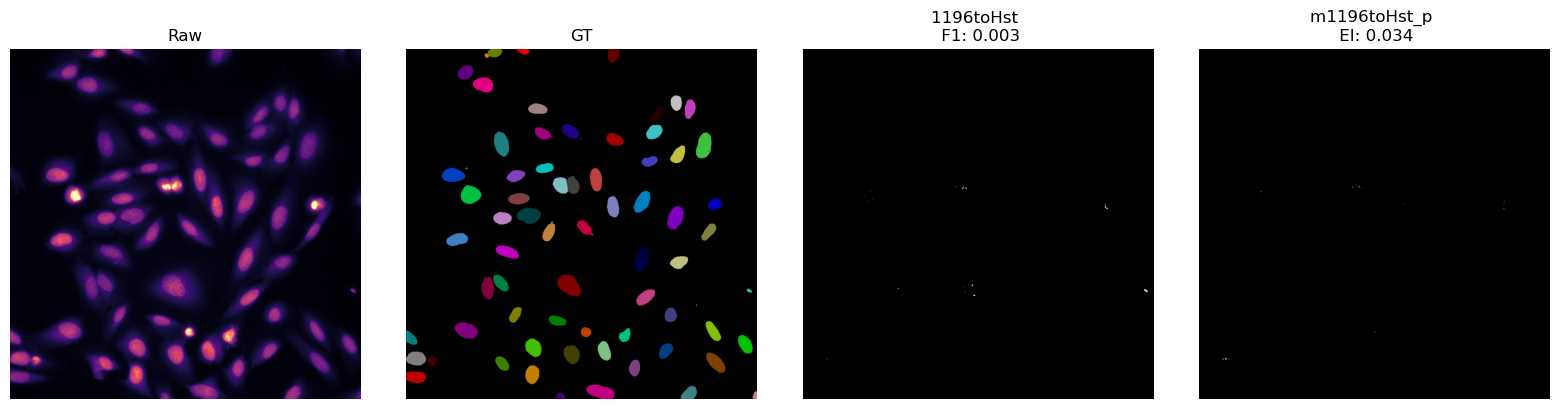

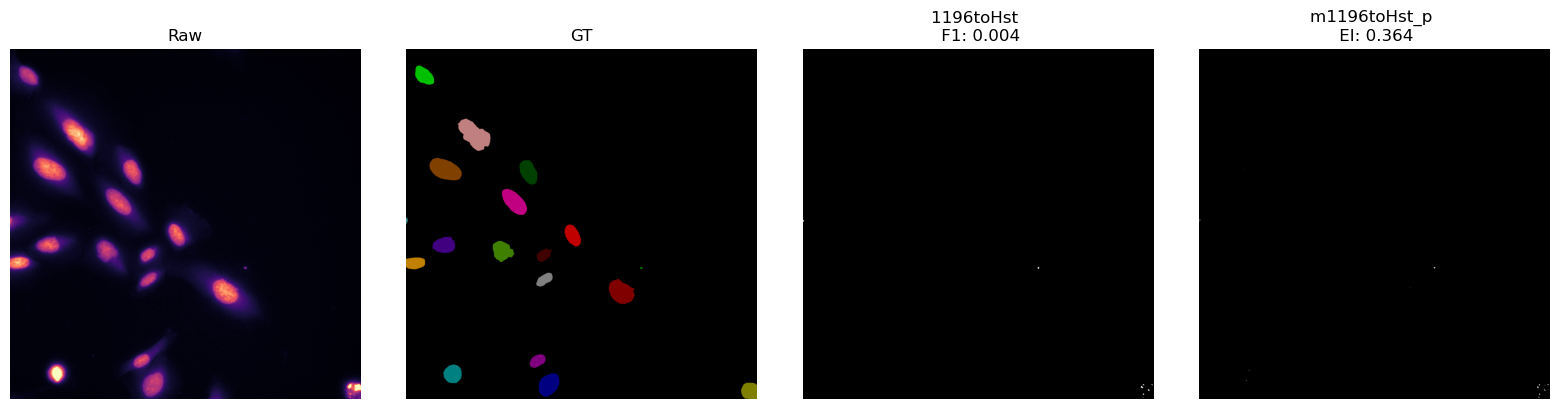

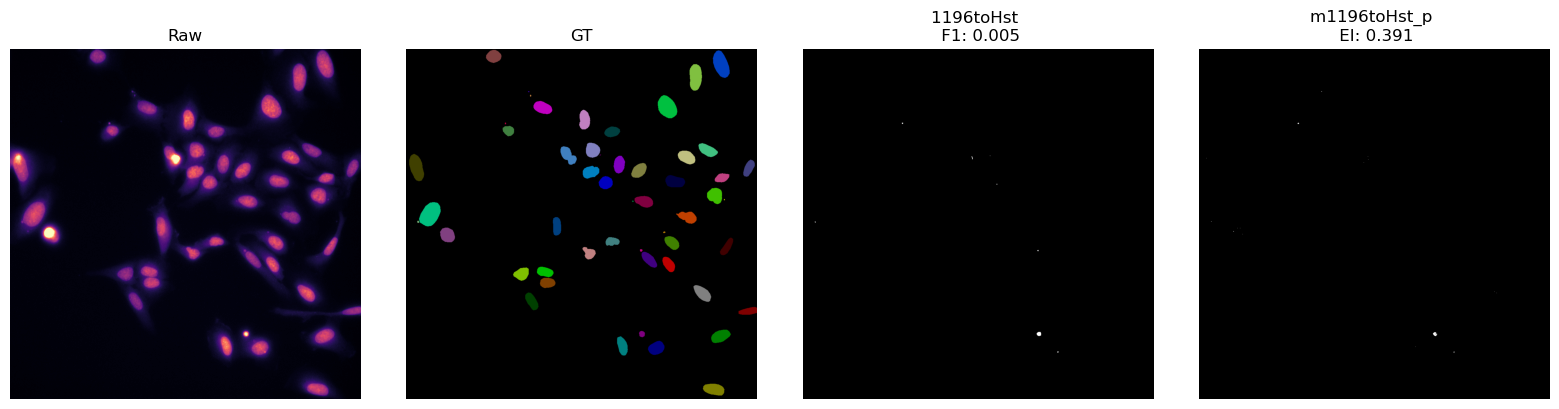

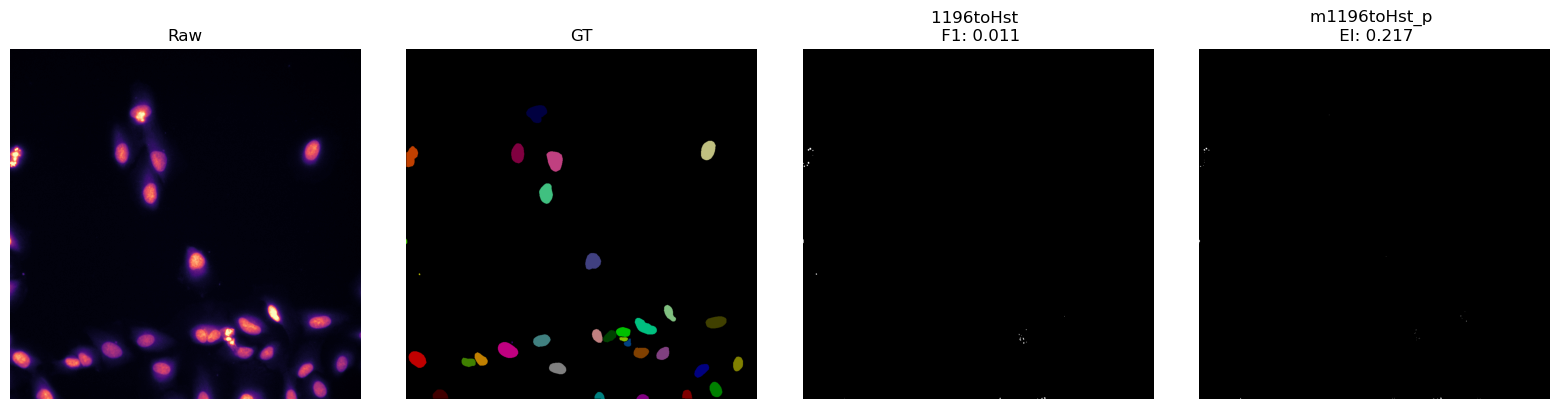

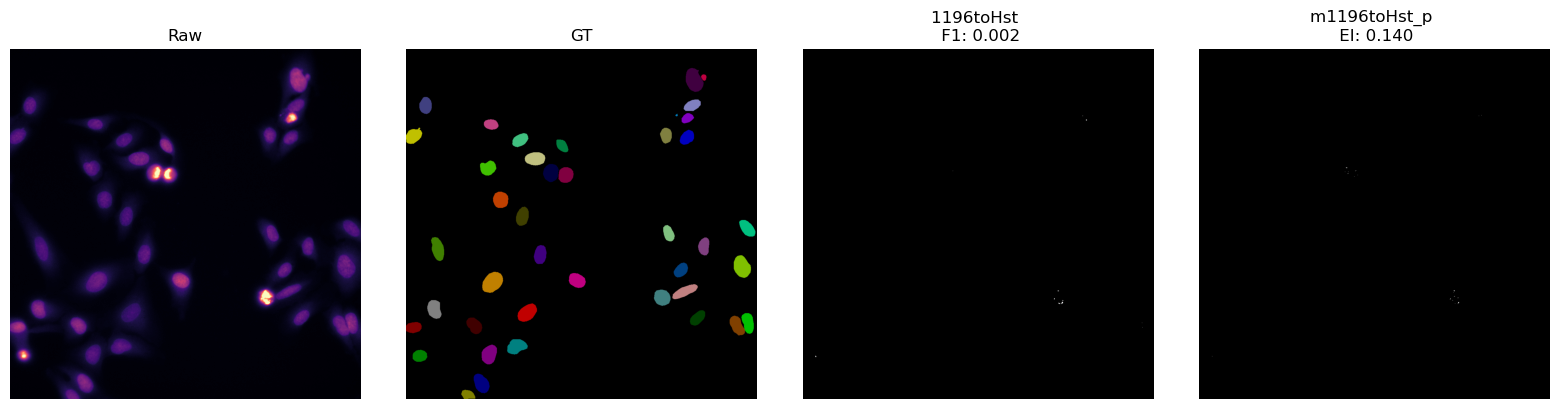

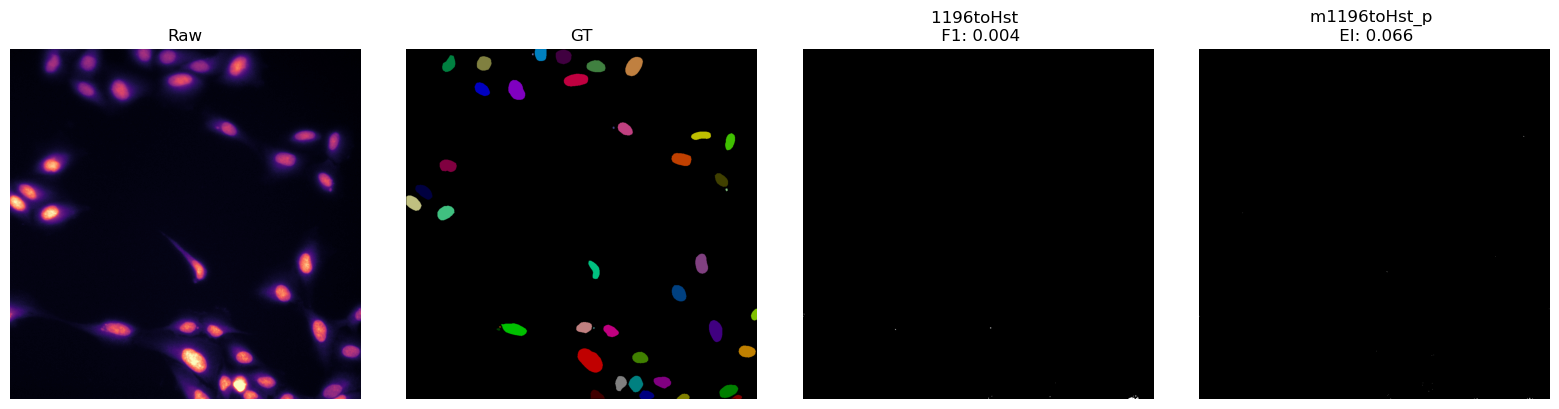

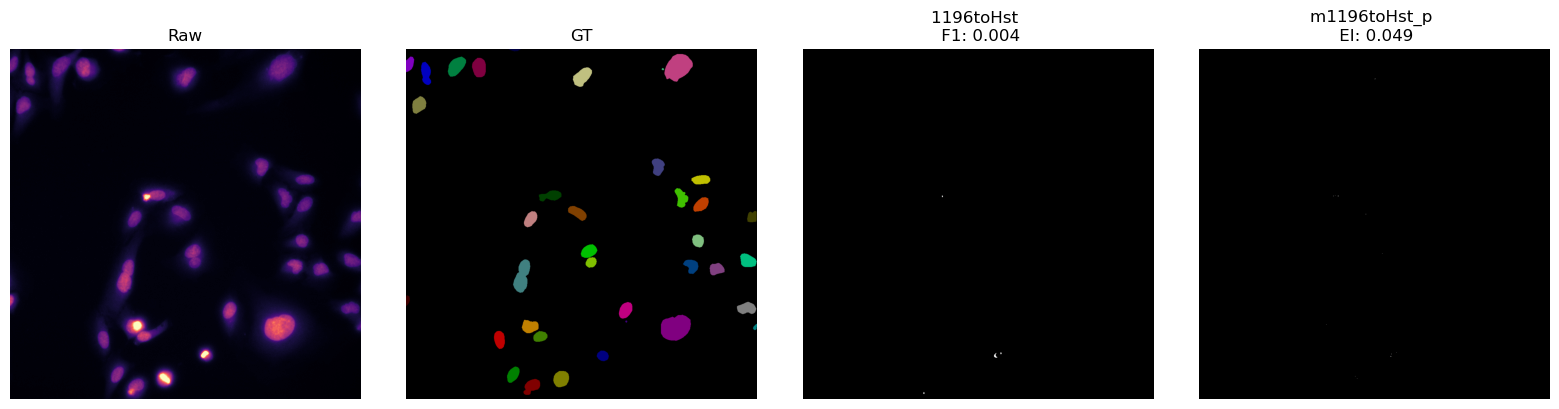

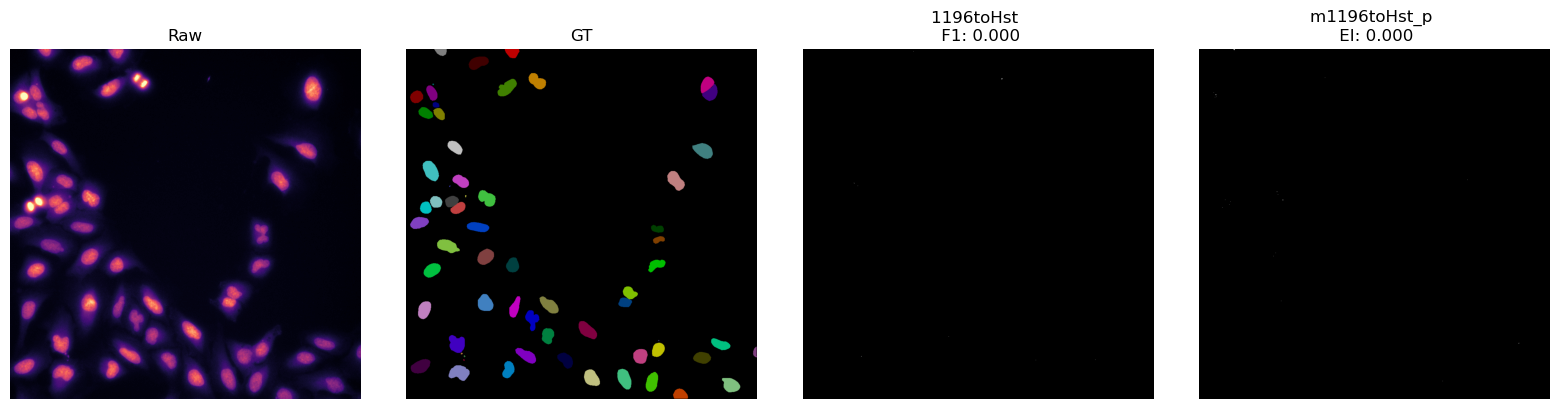

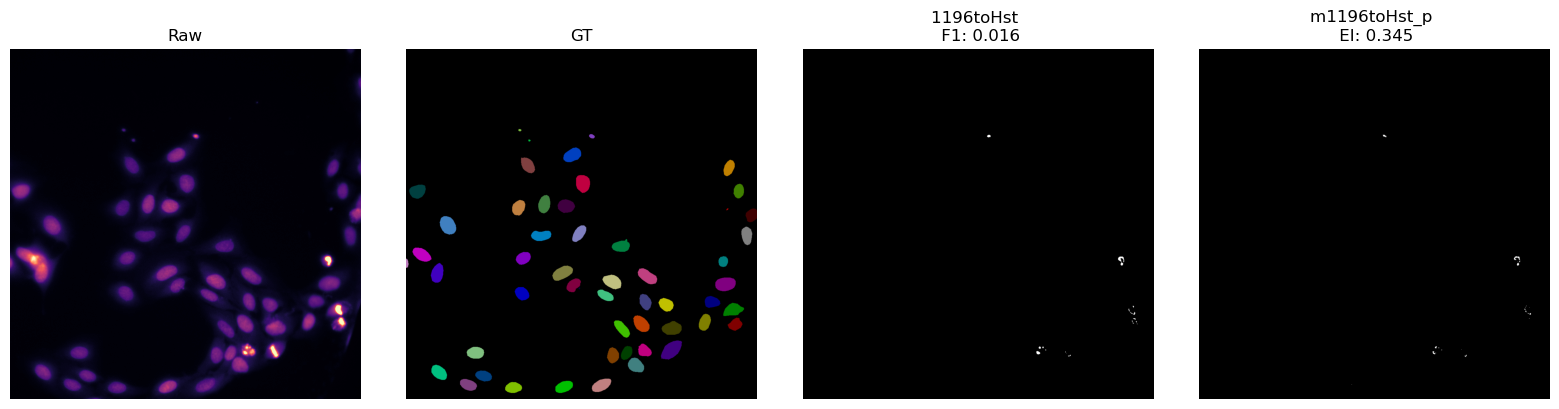

In [14]:
for raw_path in Hst_raw_path.glob("*.png"):
    name = raw_path.stem
    gt_path = Hst_gt_path / f"{name}_objects.png"
    unp_pred_path = m1196_to_Hst_pred_path / f"{name}_predictions.h5"
    p_pred_path = m1196_to_Hst_p_pred_path / f"{name}_predictions.h5"
    gt = iio.imread(gt_path)
    raw = iio.imread(raw_path)
    m1196_to_Hst_pred = load_h5(unp_pred_path, "predictions")
    f1_score = load_h5(unp_pred_path, "hard_f1")[1]
    m1196_to_Hst_p_pred = load_h5(p_pred_path, "predictions")
    EI_consis = load_h5(p_pred_path, "EI_consis")
    _, axs = plt.subplots(1,4, figsize=(16,4))
    axs[0].imshow(raw.squeeze(), cmap="magma")
    axs[0].set_title("Raw")
    axs[1].imshow(gt.squeeze(), cmap="grey")
    axs[1].set_title("GT")
    axs[2].imshow(m1196_to_Hst_pred.squeeze()>0.5, cmap="grey")
    axs[2].set_title("1196toHst \n F1: {:.3f}".format(f1_score))
    axs[3].imshow(m1196_to_Hst_p_pred.squeeze()>0.5, cmap="grey")
    axs[3].set_title("m1196toHst_p \n EI: {:.3f}".format(EI_consis))
    for ax in axs:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# S_BIAD895 Dataset

In [49]:
raw_path_895 = Path("/g/kreshuk/talks/data/S-BIAD895/ZeroCostDL4Mic/Stardist_v2/Stardist/Train/Raw")
gt_path_895 = Path("/g/kreshuk/talks/data/S-BIAD895/ZeroCostDL4Mic/Stardist_v2/Stardist/Train/Masks")

### 1196_model3 Predictions

In [50]:
unp_path_1196to895 = Path("/g/kreshuk/talks/consistency_results/patch_segmentation/nuclei/S_BIAD1196_to_S_BIAD895_gap/consistency/P_1/1196_model3/norm_50_980/none/predictions")
p_path_1196to895 = Path("/g/kreshuk/talks/consistency_results/patch_segmentation/nuclei/S_BIAD1196_to_S_BIAD895_gap/consistency/P_1/1196_model3/norm_50_980/gauss_a025-03/predictions")

In [51]:
unp_ms_1196_path = Path("/g/kreshuk/talks/consistency_results/patch_segmentation/nuclei/S_BIAD1196_to_S_BIAD895_gap/consistency/P_1/1196_model3/norm_50_980/none/metric_summary.h5")
f1_scores_1196 = load_h5(unp_ms_1196_path, "hard_f1")[:, 1]
p_ms_1196_path = Path("/g/kreshuk/talks/consistency_results/patch_segmentation/nuclei/S_BIAD1196_to_S_BIAD895_gap/consistency/P_1/1196_model3/norm_50_980/gauss_a02-025/metric_summary.h5")
EI_consis_scores_1196 = load_h5(p_ms_1196_path, "EI_consis")

In [52]:
np.median(f1_scores_1196), np.median(EI_consis_scores_1196)

(0.19897677, 0.31099504)

In [53]:
ids_f1_1196 = np.where((f1_scores_1196 > 0.15) & (f1_scores_1196 < 0.22))[0]
print(len(ids_f1_1196))
print(ids_f1_1196)

9
[ 0  1 16 25 26 28 29 31 42]


### Hst_model5

In [54]:
unp_path_Hstto895 = Path("/g/kreshuk/talks/consistency_results/patch_segmentation/nuclei/Hoechst_to_S_BIAD895_gap/consistency/P_1/Hst_model5/norm_50_980/none/predictions")
p_path_Hstto895 = Path("/g/kreshuk/talks/consistency_results/patch_segmentation/nuclei/Hoechst_to_S_BIAD895_gap/consistency/P_1/Hst_model5/norm_50_980/gauss_a025-03/predictions")

In [55]:
unp_ms_Hst_path = Path("/g/kreshuk/talks/consistency_results/patch_segmentation/nuclei/Hoechst_to_S_BIAD895_gap/consistency/P_1/Hst_model5/norm_50_980/none/metric_summary.h5")
f1_scores_Hst = load_h5(unp_ms_Hst_path, "hard_f1")[:, 1]
p_ms_Hst_path = Path("/g/kreshuk/talks/consistency_results/patch_segmentation/nuclei/Hoechst_to_S_BIAD895_gap/consistency/P_1/Hst_model5/norm_50_980/gauss_a025-03/metric_summary.h5")
EI_consis_scores_Hst = load_h5(p_ms_Hst_path, "EI_consis")

In [56]:
np.median(f1_scores_Hst), np.median(EI_consis_scores_Hst)

(0.7702162, 0.74820805)

In [57]:
ids_f1_Hst = np.where((f1_scores_Hst > 0.75) & (f1_scores_Hst < 0.8))[0]
print(len(ids_f1_Hst))
print(ids_f1_Hst)

12
[ 7  9 11 12 13 14 18 31 38 39 40 41]


# GN_model4

In [58]:
unp_path_GNto895 = Path("/g/kreshuk/talks/consistency_results/patch_segmentation/nuclei/Go-Nuclear_to_S_BIAD895_gap/consistency/P_1/GN_model4/norm_50_980/none/predictions")
p_path_GNto895 = Path("/g/kreshuk/talks/consistency_results/patch_segmentation/nuclei/Go-Nuclear_to_S_BIAD895_gap/consistency/P_1/GN_model4/norm_50_980/gauss_a02-025/predictions")

In [59]:
unp_ms_GN_path = Path("/g/kreshuk/talks/consistency_results/patch_segmentation/nuclei/Go-Nuclear_to_S_BIAD895_gap/consistency/P_1/GN_model4/norm_50_980/none/metric_summary.h5")
f1_scores_GN = load_h5(unp_ms_GN_path, "hard_f1")[:, 1]
p_ms_GN_path = Path("/g/kreshuk/talks/consistency_results/patch_segmentation/nuclei/Go-Nuclear_to_S_BIAD895_gap/consistency/P_1/GN_model4/norm_50_980/gauss_a02-025/metric_summary.h5")
EI_consis_scores_GN = load_h5(p_ms_GN_path, "EI_consis")

In [60]:
np.median(f1_scores_GN), np.median(EI_consis_scores_GN)

(0.9097501, 0.9061154)

In [61]:
ids_f1_GN = np.where((f1_scores_GN > 0.88) & (f1_scores_GN < 0.92))[0]
print(len(ids_f1_GN))
print(ids_f1_GN)

16
[20 21 22 24 25 26 30 31 35 36 38 39 40 41 43 44]


In [62]:
ids_union_combined = np.union1d(np.union1d(ids_f1_1196, ids_f1_Hst), ids_f1_GN)
print(f"Combined IDs: {ids_union_combined}")
print(f"Total number of combined IDs: {len(ids_union_combined)}")

Combined IDs: [ 0  1  7  9 11 12 13 14 16 18 20 21 22 24 25 26 28 29 30 31 35 36 38 39
 40 41 42 43 44]
Total number of combined IDs: 29


In [63]:
ids_intersection = np.intersect1d(np.intersect1d(ids_f1_1196, ids_f1_Hst), ids_f1_GN)
print(len(ids_intersection))
print(ids_intersection)

1
[31]


In [72]:
raw_paths = sorted(raw_path_895.glob("*.tif"))
raw = iio.imread(raw_paths[0])
print(np.max(raw), np.min(raw))

4347 1


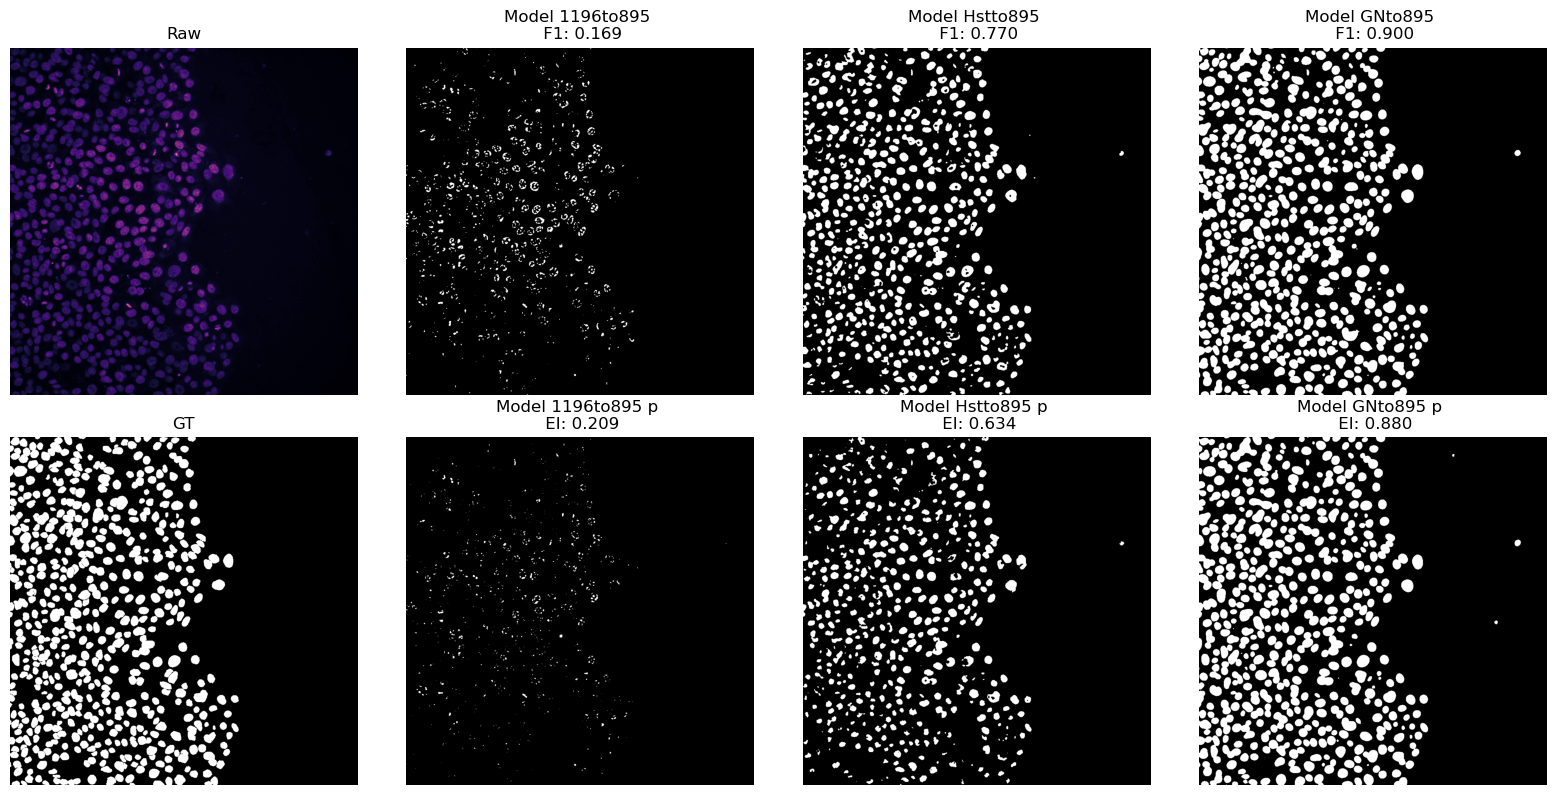

In [76]:
raw_paths = sorted(raw_path_895.glob("*.tif"))
for j in ids_intersection:
    raw_path = raw_paths[j]
    _, axs = plt.subplots(2,4, figsize=(16,8))
    name = raw_path.stem
    gt_path = gt_path_895 / f"{name}.tif"
    gt = iio.imread(gt_path)
    raw = iio.imread(raw_path)
    
    raw = Normalize(norm01=True)(raw)
    _ = axs[0,0].imshow(raw.squeeze(), cmap="magma", vmin=0, vmax=1)
    axs[0,0].axis("off")
    axs[0,0].set_title("Raw")
    _ = axs[1,0].imshow(gt.squeeze()>0, cmap="grey")
    axs[1,0].set_title("GT")
    axs[1,0].axis("off")

    models = ["1196to895", "Hstto895", "GNto895"]
    p_pred_paths = [p_path_1196to895, p_path_Hstto895, p_path_GNto895]
    unp_pred_paths = [unp_path_1196to895, unp_path_Hstto895, unp_path_GNto895]

    for i, (unp_path, p_path) in enumerate(zip(unp_pred_paths, p_pred_paths)):
        pred_path = unp_path / f"{name}_predictions.h5"
        p_pred_path = p_path / f"{name}_predictions.h5"
        unp_pred = load_h5(pred_path, "predictions")
        f1_score = load_h5(pred_path, "hard_f1")[1]
        p_pred = load_h5(p_pred_path, "predictions")
        EI_consis = load_h5(p_pred_path, "EI_consis")
        _ = axs[0, i+1].imshow(unp_pred.squeeze()>0.5, cmap="grey")
        axs[0, i+1].axis("off")
        _ = axs[0, i+1].set_title(f"Model {models[i]} \n F1: {f1_score:.3f}")
        _ = axs[1, i+1].imshow(p_pred.squeeze()>0.5, cmap="grey")
        axs[1, i+1].axis("off")
        _ = axs[1, i+1].set_title(f"Model {models[i]} p \n EI: {EI_consis:.3f}")
    plt.tight_layout()
    plt.show()

# Figure plots

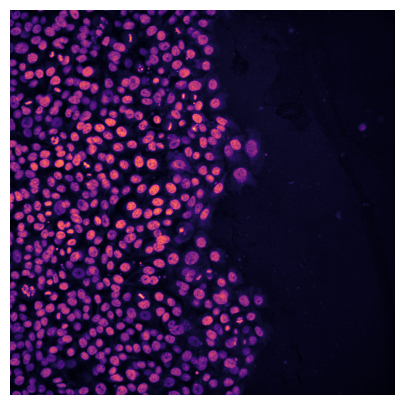

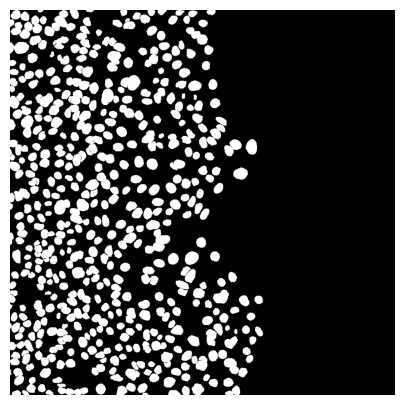

In [81]:
i = 31
raw_paths = sorted(raw_path_895.glob("*.tif"))
raw_path = raw_paths[i]

name = raw_path.stem
gt_path = gt_path_895 / f"{name}.tif"
gt = iio.imread(gt_path)
raw = iio.imread(raw_path)
raw = Normalize(norm01=True)(raw)
# change dtype of array to float32
raw = raw.astype(np.float32)
raw_enhanced = enhance_image(raw)

_ = plt.figure(figsize=(5,5))
_ = plt.imshow(raw_enhanced.squeeze(), cmap="magma")
_ = plt.axis('off')
_ = plt.savefig('/g/kreshuk/talks/model_ranking/notebooks/CVPR_Figures/semantic_imgs_nuclei/895_raw.png', bbox_inches='tight', pad_inches=0)
plt.show()

_ = plt.figure(figsize=(5,5))
_ = plt.imshow(gt.squeeze()>0, cmap="gray")
_ = plt.axis('off')
_ = plt.savefig('/g/kreshuk/talks/model_ranking/notebooks/CVPR_Figures/semantic_imgs_nuclei/895_gt.png', bbox_inches='tight', pad_inches=0)
plt.show()

### 1196_model3 Prediciton

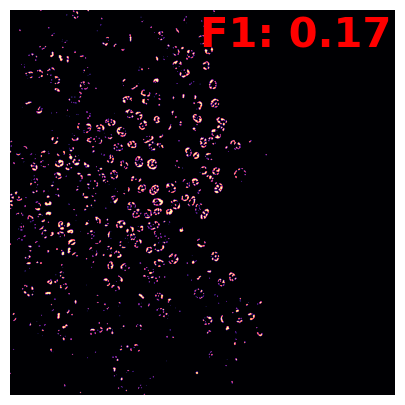

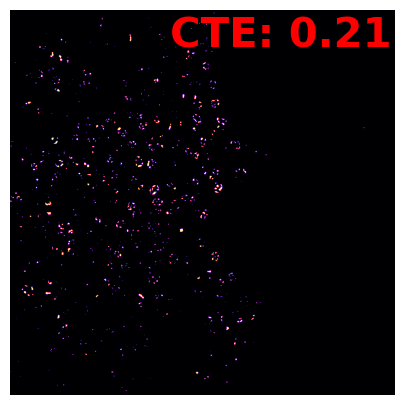

In [92]:
font_size = 30

p_path = p_path_1196to895
unp_path = unp_path_1196to895
name = raw_path.stem

pred_path = unp_path / f"{name}_predictions.h5"
p_pred_path = p_path / f"{name}_predictions.h5"
unp_pred = load_h5(pred_path, "predictions")
f1_score = load_h5(pred_path, "hard_f1")[1]
p_pred = load_h5(p_pred_path, "predictions")
EI_consis = load_h5(p_pred_path, "EI_consis")

fig, axs = plt.subplots(1, 1, figsize=(15, 5))
_ = axs.imshow(unp_pred.squeeze()>0.5, cmap='magma')
_ = axs.axis('off')

# Add mSA score as red text in lower right corner
_ = axs.text(0.99, 0.88, f"F1: {f1_score:.2f}", 
            transform=axs.transAxes, fontsize=font_size, color='red',
            ha='right', va='bottom', fontweight='bold')
             
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/CVPR_Figures/semantic_imgs_nuclei/1196_id31_unp_pred.png", bbox_inches='tight', pad_inches=0)
plt.show()

fig, axs = plt.subplots(1, 1, figsize=(15, 5))
_ = axs.imshow(p_pred.squeeze()>0.5, cmap='magma')
_ = axs.axis('off')

# Add mSA score as red text in lower right corner
_ = axs.text(0.99, 0.88, f"CTE: {EI_consis:.2f}", 
            transform=axs.transAxes, fontsize=font_size, color='red',
            ha='right', va='bottom', fontweight='bold')
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/CVPR_Figures/semantic_imgs_nuclei/1196_id31_p_pred.png", bbox_inches='tight', pad_inches=0)
plt.show()


# Hst_model5

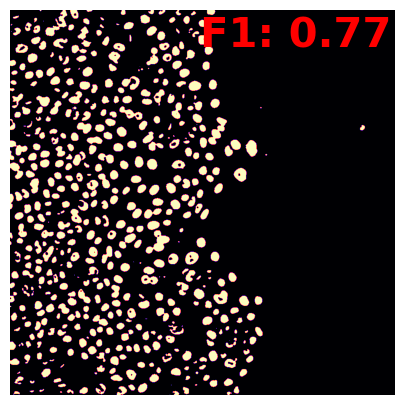

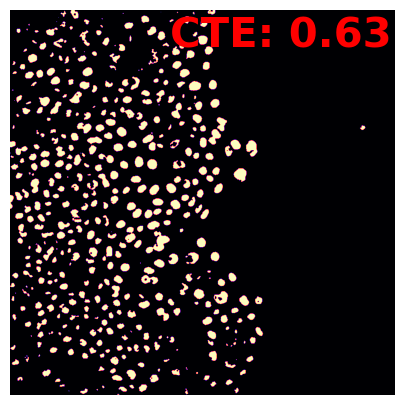

In [94]:
font_size = 30

p_path = p_path_Hstto895
unp_path = unp_path_Hstto895
name = raw_path.stem

pred_path = unp_path / f"{name}_predictions.h5"
p_pred_path = p_path / f"{name}_predictions.h5"
unp_pred = load_h5(pred_path, "predictions")
f1_score = load_h5(pred_path, "hard_f1")[1]
p_pred = load_h5(p_pred_path, "predictions")
EI_consis = load_h5(p_pred_path, "EI_consis")

fig, axs = plt.subplots(1, 1, figsize=(15, 5))
_ = axs.imshow(unp_pred.squeeze()>0.5, cmap='magma')
_ = axs.axis('off')

# Add mSA score as red text in lower right corner
_ = axs.text(0.99, 0.88, f"F1: {f1_score:.2f}", 
            transform=axs.transAxes, fontsize=font_size, color='red',
            ha='right', va='bottom', fontweight='bold')
             
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/CVPR_Figures/semantic_imgs_nuclei/Hst_id31_unp_pred.png", bbox_inches='tight', pad_inches=0)
plt.show()

fig, axs = plt.subplots(1, 1, figsize=(15, 5))
_ = axs.imshow(p_pred.squeeze()>0.5, cmap='magma')
_ = axs.axis('off')

# Add mSA score as red text in lower right corner
_ = axs.text(0.99, 0.88, f"CTE: {EI_consis:.2f}", 
            transform=axs.transAxes, fontsize=font_size, color='red',
            ha='right', va='bottom', fontweight='bold')
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/CVPR_Figures/semantic_imgs_nuclei/Hst_id31_p_pred.png", bbox_inches='tight', pad_inches=0)
plt.show()


# GN_model4

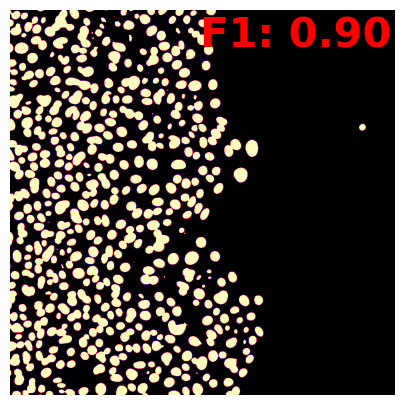

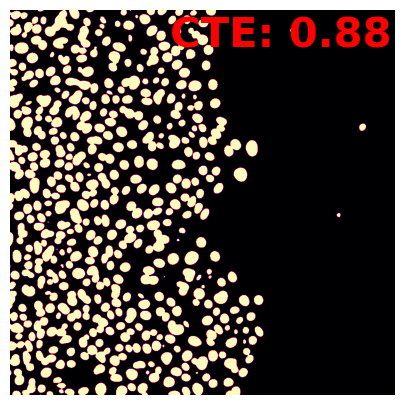

In [95]:
font_size = 30

p_path = p_path_GNto895
unp_path = unp_path_GNto895
name = raw_path.stem

pred_path = unp_path / f"{name}_predictions.h5"
p_pred_path = p_path / f"{name}_predictions.h5"
unp_pred = load_h5(pred_path, "predictions")
f1_score = load_h5(pred_path, "hard_f1")[1]
p_pred = load_h5(p_pred_path, "predictions")
EI_consis = load_h5(p_pred_path, "EI_consis")

fig, axs = plt.subplots(1, 1, figsize=(15, 5))
_ = axs.imshow(unp_pred.squeeze()>0.5, cmap='magma')
_ = axs.axis('off')

# Add mSA score as red text in lower right corner
_ = axs.text(0.99, 0.88, f"F1: {f1_score:.2f}", 
            transform=axs.transAxes, fontsize=font_size, color='red',
            ha='right', va='bottom', fontweight='bold')
             
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/CVPR_Figures/semantic_imgs_nuclei/GN_id31_unp_pred.png", bbox_inches='tight', pad_inches=0)
plt.show()

fig, axs = plt.subplots(1, 1, figsize=(15, 5))
_ = axs.imshow(p_pred.squeeze()>0.5, cmap='magma')
_ = axs.axis('off')

# Add mSA score as red text in lower right corner
_ = axs.text(0.99, 0.88, f"CTE: {EI_consis:.2f}", 
            transform=axs.transAxes, fontsize=font_size, color='red',
            ha='right', va='bottom', fontweight='bold')
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/CVPR_Figures/semantic_imgs_nuclei/GN_id31_p_pred.png", bbox_inches='tight', pad_inches=0)
plt.show()
